In [1]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [2]:
import os

os.environ['KAGGLE_USERNAME'] = 'lamasaad00'
os.environ['KAGGLE_KEY'] = 'KGAT_b3e3adc1eeceb44fba05723ada7ad5cc'

In [3]:
!pip install kaggle

In [4]:
!kaggle datasets download -d landrykezebou/vcor-vehicle-color-recognition-dataset

Dataset URL: https://www.kaggle.com/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset
License(s): copyright-authors
100% 574M/574M [00:37<00:00, 16.1MB/s]



In [5]:
!unzip vcor-vehicle-color-recognition-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/orange/e4f9205ccc.jpg  
  inflating: train/orange/e532c363be.jpg  
  inflating: train/orange/e5d2677717.jpg  
  inflating: train/orange/e6bbd5bd7c.jpg  
  inflating: train/orange/e6c8c2eb92.jpg  
  inflating: train/orange/e734cc9748.jpg  
  inflating: train/orange/e75ad9cbe4.jpg  
  inflating: train/orange/e7793a0aef.jpg  
  inflating: train/orange/e8005c8ac5.jpg  
  inflating: train/orange/e85a7f559d.jpg  
  inflating: train/orange/e865d8da86.jpg  
  inflating: train/orange/e8fd7563ed.jpg  
  inflating: train/orange/ea48d0930b.jpg  
  inflating: train/orange/ea71c13a20.jpg  
  inflating: train/orange/ea75ce4328.jpg  
  inflating: train/orange/eacc03787d.jpg  
  inflating: train/orange/eae2b8608d.jpg  
  inflating: train/orange/eb25a96e49.jpg  
  inflating: train/orange/eb704000fa.jpg  
  inflating: train/orange/ebd0009374.jpg  
  inflating: train/orange/ef030538af.jpg  
  inflating: train/orange/ef6959e880.jpg  
  i

In [6]:
!ls

sample_data  test  train  val  vcor-vehicle-color-recognition-dataset.zip


In [7]:
import os

classes = os.listdir("train")
print(classes)

['pink', 'gold', 'white', 'red', 'grey', 'blue', 'beige', 'green', 'black', 'orange', 'yellow', 'purple', 'tan', 'silver', 'brown']


In [9]:
import os
import shutil

selected_classes = ['black', 'blue', 'red', 'white', 'silver', 'grey']

base_dirs = ['train', 'val', 'test']
new_base = 'filtered_vcor'

for split in base_dirs:
    for cls in selected_classes:
        src = os.path.join(split, cls)
        dst = os.path.join(new_base, split, cls)
        os.makedirs(dst, exist_ok=True)

        for file_name in os.listdir(src):
            shutil.copy(os.path.join(src, file_name), os.path.join(dst, file_name))

print("Done")

Done


In [40]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

train_dir = 'filtered_vcor/train'
val_dir = 'filtered_vcor/val'
test_dir = 'filtered_vcor/test'

train_datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.5, 1.5]
)

val_test_datagen = ImageDataGenerator()

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 2978 images belonging to 6 classes.
Found 635 images belonging to 6 classes.
Found 637 images belonging to 6 classes.


In [41]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

num_classes = train_data.num_classes

base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 85s 686ms/step - accuracy: 0.6706 - loss: 0.8893 - val_accuracy: 0.8173 - val_loss: 0.5003
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 46s 492ms/step - accuracy: 0.8012 - loss: 0.5048 - val_accuracy: 0.8315 - val_loss: 0.4349
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 46s 486ms/step - accuracy: 0.8388 - loss: 0.4285 - val_accuracy: 0.8661 - val_loss: 0.3771
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 56s 597ms/step - accuracy: 0.8533 - loss: 0.3913 - val_accuracy: 0.8756 - val_loss: 0.3465
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 56s 594ms/step - accuracy: 0.8724 - loss: 0.3565 - val_accuracy: 0.8803 - val_loss: 0.3259
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 53s 568ms/step - accuracy: 0.8771 - loss: 0.3325 - val_accuracy: 0.8535 - val_loss: 0.3663
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 470ms/step - accuracy: 0.8902 - loss: 0.3009 - val_accuracy: 0.8787 - val_loss: 0.3312
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 46s 487ms/step - accuracy: 0.8862 - loss: 0.3078 - val_accu

In [45]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 428ms/step - accuracy: 0.8713 - loss: 0.3607
Test Loss: 0.3606736361980438
Test Accuracy: 0.8712716102600098


In [43]:
model.save("car_color_model_augmented.keras")
model.save("car_color_model_augmented.h5")

In [44]:
from google.colab import files
files.download("car_color_model_augmented.keras")
files.download("car_color_model_augmented.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving WhatsApp Image 2026-04-02 at 4.30.19 PM.jpeg to WhatsApp Image 2026-04-02 at 4.30.19 PM.jpeg


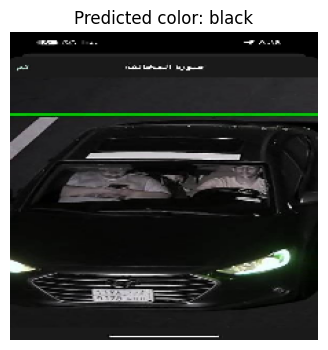

Image: WhatsApp Image 2026-04-02 at 4.30.19 PM.jpeg
black: 0.8449
blue: 0.0020
grey: 0.1411
red: 0.0082
silver: 0.0020
white: 0.0019
------------------------------


In [58]:
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

uploaded = files.upload()
class_names = list(train_data.class_indices.keys())

for img_path in uploaded.keys():
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(prediction)]

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Predicted color: {predicted_class}")
    plt.axis('off')
    plt.show()

    print(f"Image: {img_path}")
    for i, prob in enumerate(prediction[0]):
        print(f"{class_names[i]}: {prob:.4f}")
    print("-" * 30)

In [57]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

class_names = list(train_data.class_indices.keys())
print(class_names)

['black', 'blue', 'grey', 'red', 'silver', 'white']
